# Pipeline Sandbox - Tech Challenge Fase 4

Notebook didático para demonstrar o mesmo fluxo implementado em `src/train.py`: coleta, uso da coluna `Close`, transformação em log-retornos, criação de janelas, LSTM, treino, avaliação e geração dos artefatos consumidos pela API.

## 1. Imports e configuração

Importamos os módulos do projeto: `data_loader.py` para dados, `model.py` para a LSTM e `train.py` para o pipeline oficial.

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

from data_loader import load_yfinance, load_csv, build_close_frame, build_return_frame
from model import StockLSTM
from train import TrainConfig, fit_preprocessor, create_windows, run_training_pipeline

# Resolução limpa de caminhos para o modelo a partir do .env
model_dir = os.getenv("MODEL_DIR", "models/lstm_petr4")
MODEL_PATH = Path(model_dir) if Path(model_dir).is_absolute() else PROJECT_ROOT / model_dir

cfg = TrainConfig(
    symbol="PETR4.SA",
    start_date="2018-01-01",
    output_dir=str(MODEL_PATH),
    window_size=60,
    max_epochs=80,
    patience=10,
    batch_size=32,
    learning_rate=1e-3,
    dropout=0.20,
)
cfg

TrainConfig(symbol='PETR4.SA', start_date='2018-01-01', end_date=None, window_size=60, train_ratio=0.7, val_ratio=0.15, hidden_size=64, num_layers=1, dropout=0.2, learning_rate=0.001, weight_decay=0.0001, batch_size=32, max_epochs=80, patience=10, output_dir='h:\\dev\\fiap_tech_cha_fase4\\models\\lstm_petr4', seed=42)

## 2. Coleta dos dados

Baixamos os dados históricos pelo Yahoo Finance. O pipeline usa apenas a coluna `Close` para o treinamento.

In [2]:
csv_path = os.getenv("DATA_CSV_PATH")
if csv_path:
    csv_path = Path(csv_path) if Path(csv_path).is_absolute() else PROJECT_ROOT / csv_path
    df_raw = load_csv(csv_path)
else:
    df_raw = load_yfinance(cfg.symbol, cfg.start_date, cfg.end_date)
print(df_raw.shape)
df_raw.tail()

(2079, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-05-11,46.430000,46.430000,46.509998,45.650002,46.209999,50622200
2026-05-12,45.680000,45.680000,46.250000,45.400002,46.250000,81072700
2026-05-13,44.570000,44.570000,45.830002,44.360001,45.770000,57251900
2026-05-14,45.000000,45.000000,45.369999,44.380001,44.459999,47760000
2026-05-15,45.470001,45.470001,45.540001,44.980000,45.389999,59380500


## 3. Série de fechamentos

Limpamos e ordenamos a série de preços de fechamento, removendo valores inválidos.

In [3]:
close_frame = build_close_frame(df_raw)
print(close_frame.shape)
close_frame.tail()

(2079, 1)


,Close
Date,
2026-05-11,46.430000
2026-05-12,45.680000
2026-05-13,44.570000
2026-05-14,45.000000
2026-05-15,45.470001


## 4. Log-retornos

Em vez de treinar a LSTM diretamente no preço bruto, transformamos fechamentos em log-retornos:

`log_return_t = log(close_t / close_t-1)`

Depois da previsão, voltamos para preço com:

`predicted_close = last_close * exp(predicted_log_return)`

In [4]:
return_frame = build_return_frame(df_raw)
print(return_frame.shape)
return_frame.tail()

(2078, 2)


,Close,Log_Return
Date,,
2026-05-11,46.430000,0.016504
2026-05-12,45.680000,-0.016285
2026-05-13,44.570000,-0.024600
2026-05-14,45.000000,0.009602
2026-05-15,45.470001,0.010390


## 5. Split temporal e janelas

A divisão respeita a ordem temporal. O scaler é ajustado apenas no trecho de treino para evitar vazamento de dados.

In [5]:
n_rows = len(return_frame)
train_end_row = int(n_rows * cfg.train_ratio)
val_end_row = int(n_rows * (cfg.train_ratio + cfg.val_ratio))

preprocessor = fit_preprocessor(return_frame, train_end_row, cfg.window_size)
X_all, y_all, last_close_all, target_close_all, dates_all, rows_all = create_windows(return_frame, preprocessor)

train_mask = rows_all < train_end_row
val_mask = (rows_all >= train_end_row) & (rows_all < val_end_row)
test_mask = rows_all >= val_end_row

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)
print("Último fechamento exemplo:", last_close_all[-1])
print("Fechamento alvo exemplo:", target_close_all[-1])

Treino: (1394, 60, 1) (1394, 1)
Validação: (312, 60, 1) (312, 1)
Teste: (312, 60, 1) (312, 1)
Último fechamento exemplo: 45.0
Fechamento alvo exemplo: 45.47


## 6. Modelo LSTM

A entrada possui formato `(amostras, window_size, 1)`, pois usamos uma única feature: o log-retorno escalonado.

In [6]:
model = StockLSTM(
    input_size=X_train.shape[2],
    hidden_size=cfg.hidden_size,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
)
model

StockLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## 7. Treinamento completo

Executa o pipeline oficial de ponta a ponta: treino, validação, teste, métricas, baseline e geração dos artefatos.

A visualização principal fica salva em `model_performance.png`, separando treino, validação, teste real e previsão da LSTM.

In [7]:
import pandas as pd
from IPython.display import display

results = run_training_pipeline(cfg)
metrics = results["metrics"]

metrics_df = pd.DataFrame(
    [
        {"modelo": "LSTM", **metrics["lstm"]},
        {"modelo": "Baseline último fechamento", **metrics["baseline_last_close"]},
    ]
).set_index("modelo")

display(metrics_df.round(4))

directional_acc = metrics.get("lstm_directional_accuracy_pct")
if directional_acc is not None:
    print(f"Acurácia direcional LSTM: {directional_acc:.2f}%")

gain = metrics.get("relative_gain_vs_baseline_pct")
if gain:
    print("Ganho percentual vs baseline:")
    display(pd.DataFrame([gain]).round(4))

Dataset
- fonte: yfinance
- periodo: 2018-01-02 ate 2026-05-15
- fechamentos: 2079
- log-retornos: 2078
Janelas
- X_train: (1394, 60, 1)
- X_val:   (312, 60, 1)
- X_test:  (312, 60, 1)
Device: cuda
Epoch 001 | train=0.00165320 | val=0.00039682
Epoch 010 | train=0.00104936 | val=0.00026541
Epoch 020 | train=0.00098341 | val=0.00027179
Early stopping na epoca 29.

Metricas no teste
- LSTM MAE:  0.4335 | Baseline MAE:  0.4356
- LSTM RMSE: 0.6097 | Baseline RMSE: 0.6135
- LSTM MAPE: 1.20% | Baseline MAPE: 1.21%

Artefatos salvos em: h:\dev\fiap_tech_cha_fase4\models\lstm_petr4


,mae,rmse,mape_pct
modelo,,,
LSTM,0.4335,0.6097,1.2025
Baseline último fechamento,0.4356,0.6135,1.2081


Acurácia direcional LSTM: 48.40%
Ganho percentual vs baseline:


,mae,rmse,mape
0,0.4813,0.6155,0.4651


## 8. Artefatos gerados

Esses arquivos são carregados pela API de inferência.

In [8]:
artifact_dir = Path(cfg.output_dir)
for path in sorted(artifact_dir.glob("*")):
    print(path.name)

.gitkeep
history.json
metadata.json
metrics.json
model.pt
model_performance.png
preprocessor.joblib
test_predictions.csv


## 9. Avaliação visual

Gráfico salvo pelo pipeline, no estilo mais direto:

- série original no treino;
- série original na validação;
- série real no teste;
- previsão da LSTM no teste.

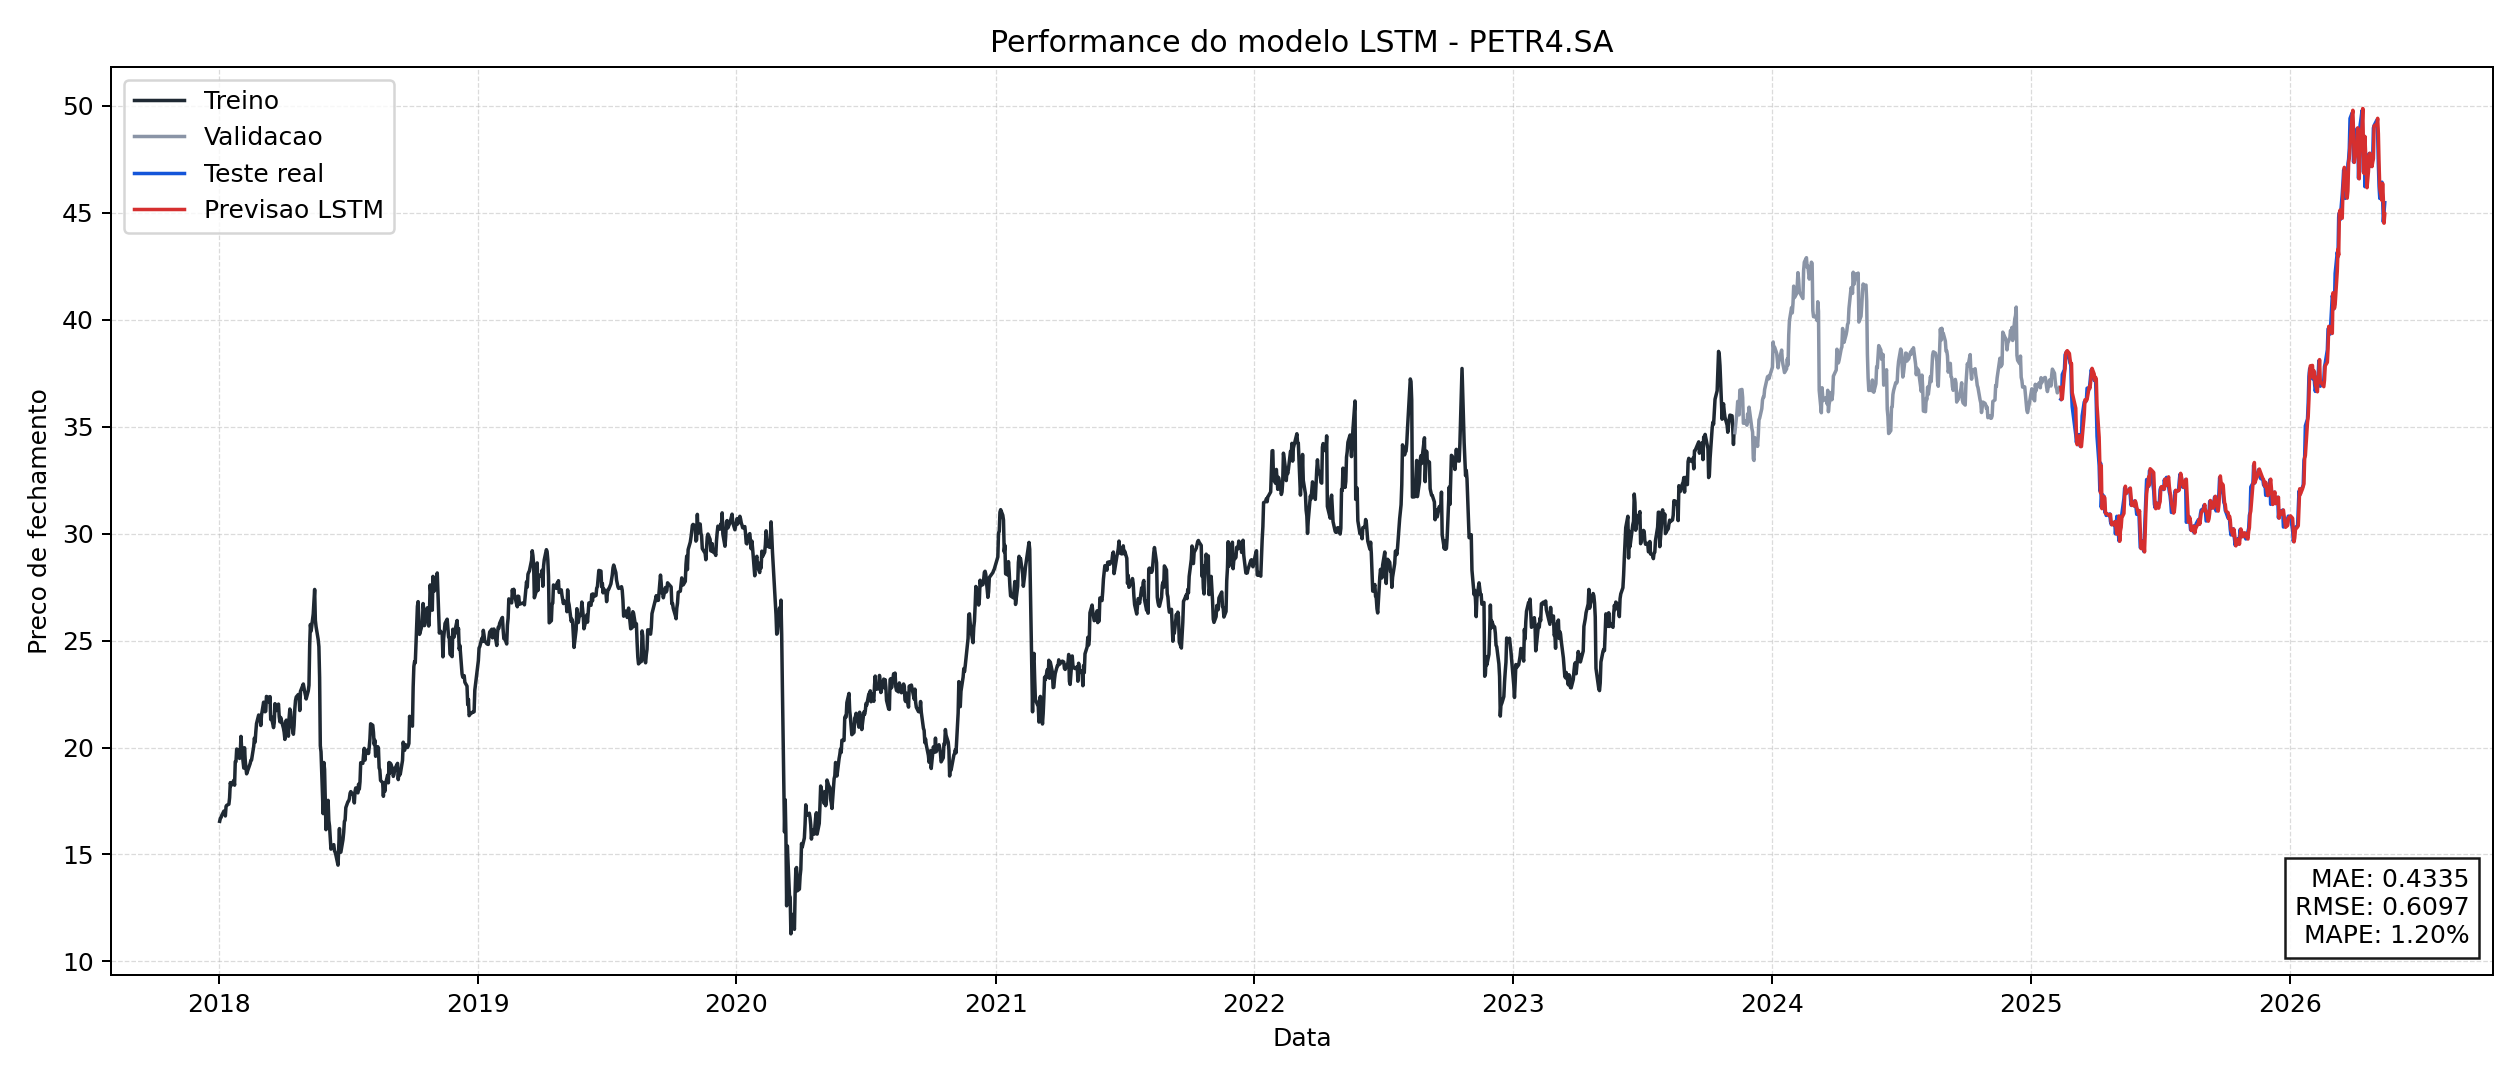

In [9]:
from IPython.display import Image, display

plot_path = artifact_dir / "model_performance.png"

if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("Gráfico ainda não encontrado. Rode a célula de treinamento primeiro.")

## 10. Payload para a API

A API agora recebe apenas uma lista cronológica de fechamentos. Com `window_size=60`, envie pelo menos 61 fechamentos para gerar 60 log-retornos.

In [10]:
recent_closes = close_frame["Close"].tail(cfg.window_size + 1).astype(float).tolist()
payload = {
    "symbol": cfg.symbol,
    "closes": recent_closes,
}

payload["closes"][:3], payload["closes"][-3:], len(payload["closes"])

([36.88999938964844, 37.189998626708984, 37.810001373291016],
 [44.56999969482422, 45.0, 45.470001220703125],
 61)

## 11. Próximos passos da demonstração

Com os artefatos salvos, suba a API no PowerShell com:

```powershell
$env:PYTHONPATH="src"; uvicorn api:app --reload
```

Depois acesse:

- `http://localhost:8000/` para abrir direto o dashboard;
- `http://localhost:8000/dashboard` para inferência visual e telemetria;
- `http://localhost:8000/docs` para Swagger;
- `http://localhost:8000/model-card` para resumo do modelo;
- `http://localhost:8000/metrics` para Prometheus.